> **Purpose:** p* ∝ η(1+η)³ log(m) / [m(ρ − η·S_out)²].  
> **Data:** synthesized

# Figure 3 — Non-Balanced CBM, Synthetic Similarity

Empirical validation of the Non-Balanced CBM theorem on a synthetic similarity matrix:
$S_{ij} = S_{\text{in}}$ within clan, $S_{ij} = S_{\text{out}}$ across clan, diagonal zero.

**Theorem:** For a flat CBM with $m$ terminal nodes and imbalance $\eta \ge 1$, successful
Fiedler-vector recovery (with probability $\ge 1-\varepsilon$) requires the sampling
probability $p$ to satisfy:
$$
p > \frac{C \cdot \eta(1+\eta)^3 \log m}{m \cdot (\rho - \eta \cdot S_{\text{out}}^{\max})^2}
$$
where $\rho = S_{\text{in}} - S_{\text{out}}$ (molecular clock) and the denominator
requires $\rho > \eta \cdot S_{\text{out}}$.

This is the direct non-balanced analogue of the balanced-binary bound $p > C\ln n / n$:
the extra $\eta(1+\eta)^3 / (\rho - \eta S_{\text{out}})^2$ factor captures how
imbalance and the signal margin raise the required sampling probability.

**Sweep plan:** For each $\eta \in \{1, 2, 4, 8\}$ we sweep total size
$m \in \{90, 180, 360, 720, 1440, 2880\}$ and report one two-panel figure:
- **Left panel:** recovery vs $p$ (one curve per $m$, viridis colormap).
- **Right panel:** empirical $\hat{p}^*(m)$ with the theoretical scaling overlay.

All heavy computation is disk-cached under `cache/theoretical_interpretation/`.
Re-running any cell after the first pass is instant.

## Cell 1 — Configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils.sweep_plots_two_panel import (
    plot_pstar_pair, median_ratio_C,
)
from analysis.utils import (
    build_flat_cbm_S, flat_cbm_population_fiedler,
    imbalance_eta, n_min as compute_n_min, structural_margin_rho,
    compute_fiedler_of_S,
    compute_recovery, compute_nmi, find_threshold_p_star,
    make_full_key, get_or_compute_full,
    run_sweep,
    clear_theoretical_cache,
)

# eta matched to the generated-regime figure (eta_pool_sweep.ipynb) so the two
# main-text figures are read side by side.
ETA_VALUES         = [1, 5, 10, 15]
S_IN               = 0.9
S_OUT              = 0.05   # keeps ρ - η·S_out > 0 for all η ≤ 15 (margin 0.10 at η=15)
# n1 = m/(1+η) must be exact, and 1+η is 2, 6, 11, 16 -- no single grid divides
# all four, so each η gets its own list spanning the same ~two decades.
# Seven sizes, not eight: the largest tier (~11.5k) costs ~3 h per (eta, m) --
# the sub-sampled Fiedler solve is O(m^3) and dominates everything else -- for
# one extra point on a log axis. Two decades become 1.8.
M_GRIDS = {
    1:  [90, 180, 360, 720, 1440, 2880, 5760],    # /2
    5:  [90, 180, 360, 720, 1440, 2880, 5760],    # /6
    10: [88, 176, 352, 704, 1408, 2816, 5632],    # /11
    15: [96, 192, 384, 768, 1536, 3072, 6144],    # /16
}
ms_for = M_GRIDS.__getitem__
M_VALUES           = sorted({m for ms in M_GRIDS.values() for m in ms})  # plotting span only
P_GRID             = np.geomspace(1e-4, 1.0, 25)
N_TRIALS           = 8    # was 20; cost is linear in trials and p* is a
#                          grid read-off, so the extra 12 bought little
RECOVERY_THRESHOLD = 0.90   # matches the generated-regime figure
CACHE_DIR          = PROJECT_ROOT / "cache" / "theoretical_interpretation"

# Smoke-test override — uncomment for a fast end-to-end pass before the long run.
# M_GRIDS, P_GRID, N_TRIALS = {e: [90, 180, 360] for e in ETA_VALUES}, np.geomspace(1e-3, 1.0, 8), 3

# Positivity guard: ρ - η·S_out must be > 0 for the theorem bound to be finite.
rho_global = structural_margin_rho(S_IN, S_OUT, S_OUT)
print(f"S_in={S_IN}, S_out={S_OUT}, ρ={rho_global:.3f}")
print(f"m grids={M_GRIDS}")
print(f"|p_grid|={len(P_GRID)}, n_trials={N_TRIALS}")
print(f"cache_dir={CACHE_DIR}")
print()
print("Margin check per η:")
for eta in ETA_VALUES:
    margin = rho_global - eta * S_OUT
    status = "✓" if margin > 0 else "✗ INVALID"
    print(f"  η={eta}: ρ - η·S_out = {margin:.4f}  {status}")
    assert margin > 0, f"Denominator non-positive for η={eta}: {margin}"


S_in=0.9, S_out=0.05, ρ=0.850
m_values=[90, 180, 360, 720, 1440, 2880, 5760, 11520]
|p_grid|=25, n_trials=20
cache_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/cache/theoretical_interpretation

Margin check per η:
  η=1: ρ - η·S_out = 0.8000  ✓
  η=2: ρ - η·S_out = 0.7500  ✓
  η=4: ρ - η·S_out = 0.6500  ✓
  η=8: ρ - η·S_out = 0.4500  ✓


## Cell 2 — Build $S$ (and Fiedler) for each $(\eta, m)$, with caching

For each pair we split $m$ into clans $(n_1, n_2)$ with $n_1 = m \mathbin{//} (1+\eta)$,
$n_2 = m - n_1$, build the flat-CBM similarity matrix, and compute its full Fiedler vector.
Both are cached under `cache/theoretical_interpretation/full/...`.

In [2]:
full_results = {}   # full_results[eta][m] = (n1, n2, S, fiedler_full)

summary_rows = []
for eta in ETA_VALUES:
    full_results[eta] = {}
    for m in ms_for(eta):
        n1 = m // (1 + int(eta))
        n2 = m - n1
        full_key = make_full_key("flat_cbm", eta=eta, n=m, s_in=S_IN, s_out=S_OUT)

        def builder(n1=n1, n2=n2, full_key=full_key, eta=eta, m=m):
            S = build_flat_cbm_S(n1, n2, S_IN, S_OUT)
            fiedler_full = compute_fiedler_of_S(S)
            meta = {
                "tree_model": "flat_cbm",
                "eta": eta, "n1": n1, "n2": n2, "m": m,
                "s_in": S_IN, "s_out": S_OUT,
                "full_key": full_key,
            }
            return S, fiedler_full, meta

        S, fiedler_full = get_or_compute_full(CACHE_DIR, full_key, builder)
        full_results[eta][m] = (n1, n2, S, fiedler_full)
        summary_rows.append({
            "eta_target": eta,
            "m": m,
            "n1": n1,
            "n2": n2,
            "actual_eta": imbalance_eta(n1, n2),
            "S_shape": str(S.shape),
        })

pd.DataFrame(summary_rows)

,eta_target,m,n1,n2,actual_eta,S_shape
0,1,90,45,45,1.0,"(90, 90)"
1,1,180,90,90,1.0,"(180, 180)"
2,1,360,180,180,1.0,"(360, 360)"
3,1,720,360,360,1.0,"(720, 720)"
4,1,1440,720,720,1.0,"(1440, 1440)"
5,1,2880,1440,1440,1.0,"(2880, 2880)"
6,1,5760,2880,2880,1.0,"(5760, 5760)"
7,1,11520,5760,5760,1.0,"(11520, 11520)"
8,2,90,30,60,2.0,"(90, 90)"
9,2,180,60,120,2.0,"(180, 180)"


## Cell 3 — Sanity: empirical Fiedler matches closed-form flat-CBM Fiedler

The closed-form vector has constant $a$ in $C_1$ and $b$ in $C_2$ with
$n_1 a + n_2 b = 0$ and $n_1 a^2 + n_2 b^2 = 1$.
Sign-agreement should be 1.0 and magnitude error at machine precision.

In [3]:
sanity_rows = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        n1, n2, _, fiedler_full = full_results[eta][m]
        v_closed = flat_cbm_population_fiedler(n1, n2)
        agreement = compute_recovery(v_closed, fiedler_full)
        mag_err   = float(np.max(np.abs(np.abs(fiedler_full) - np.abs(v_closed))))
        sanity_rows.append({
            "eta": eta, "m": m, "n1": n1, "n2": n2,
            "sign_agreement": agreement,
            "mag_inf_err": mag_err,
        })

df_sanity = pd.DataFrame(sanity_rows)
assert (df_sanity["sign_agreement"] == 1.0).all(), "Some Fiedler vectors do not match the closed form!"
print("All sign agreements = 1.0 ✓")
df_sanity

All sign agreements = 1.0 ✓


,eta,m,n1,n2,sign_agreement,mag_inf_err
0,1,90,45,45,1.0,5.307662e-07
1,1,180,90,90,1.0,1.201135e-06
2,1,360,180,180,1.0,9.024077e-07
3,1,720,360,360,1.0,3.392944e-06
4,1,1440,720,720,1.0,4.140216e-06
5,1,2880,1440,1440,1.0,4.712094e-06
6,1,5760,2880,2880,1.0,4.218182e-06
7,1,11520,5760,5760,1.0,8.837519e-06
8,2,90,30,60,1.0,1.472033e-06
9,2,180,60,120,1.0,8.103383e-07


## Cell 4 — Sub-sampling sweep + recovery

For each $(\eta, m, p, \text{seed})$ we sub-sample $S$, recompute the Fiedler, and record
sign-agreement. Each trial is individually cached, so re-running skips finished trials.

In [4]:
sweep_rows = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        n1, n2, S, fiedler_full = full_results[eta][m]
        full_key = make_full_key("flat_cbm", eta=eta, n=m, s_in=S_IN, s_out=S_OUT)
        df_nm = run_sweep(CACHE_DIR, full_key, S, fiedler_full, P_GRID, N_TRIALS)
        df_nm["eta"] = eta
        df_nm["m"]   = m
        sweep_rows.append(df_nm)

df_long = pd.concat(sweep_rows, ignore_index=True)
# run_sweep now reports the metric column as "sign_agreement" (the legacy
# "agreement" name was retired). Aggregate it and expose it downstream under
# the short "agreement" alias the threshold/plot cells expect.
df_agg = (
    df_long.groupby(["eta", "m", "p"], as_index=False)["sign_agreement"].mean()
    .rename(columns={"sign_agreement": "agreement"})
)
print(f"df_agg shape: {df_agg.shape}")
df_agg.head()

  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 25/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 50/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 75/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 100/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 125/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 150/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 175/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 200/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 225/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 250/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0001_n00

  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 75/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 100/500 trials done


  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 125/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 150/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 175/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 200/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 225/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 250/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0001_n0180_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0001_

  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 175/500 trials done


  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 200/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 225/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 250/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 475/500 trials done
  [flat_cbm_eta0001_n0360_s_in0p9000_s_out0p0500] 500/500 trials done
  [flat_cbm_eta0001_n0720_s_in0p9000_s_out0p0500] 25/500 trials done
  [flat_cbm_eta0001_n

...

  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 475/500 trials done
  [flat_cbm_eta0008_n1440_s_in0p9000_s_out0p0500] 500/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 25/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 50/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 75/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 100/500 trials done
  [flat_cbm_eta0008_n28

  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 475/500 trials done
  [flat_cbm_eta0008_n2880_s_in0p9000_s_out0p0500] 500/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 25/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 50/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 75/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 100/500 trials done
  [flat_cbm_eta0008_n57

  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 475/500 trials done
  [flat_cbm_eta0008_n5760_s_in0p9000_s_out0p0500] 500/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 25/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 50/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 75/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 100/500 trials done
  [flat_cbm_eta0008

  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 200/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 225/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 250/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 275/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 300/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 325/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 350/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 375/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 400/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 425/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 450/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 475/500 trials done
  [flat_cbm_eta0008_n11520_s_in0p9000_s_out0p0500] 500/500 trials done
df_agg shape: (800, 4)


,eta,m,p,agreement
0,1,90,0.000100,0.5
1,1,90,0.000147,0.5
2,1,90,0.000215,0.5
3,1,90,0.000316,0.5
4,1,90,0.000464,0.5


## Cell 5 — Compute $\hat{p}^*$ thresholds and fit constant $C$

For each $(\eta, m)$ the empirical threshold $\hat{p}^*$ is the smallest $p$ in the grid
at which mean recovery $\ge 95\%$.

The theorem bound $p > C \cdot \eta(1+\eta)^3 \ln m \,/\, [m \cdot (\rho - \eta S_{\text{out}})^2]$
implies a universal constant:
$$
C_\eta = \operatorname{median}_m\!\left[\frac{\hat{p}^*(m) \cdot m \cdot (\rho - \eta S_{\text{out}})^2}
{\eta(1+\eta)^3 \ln m}\right]
$$
This is the direct analogue of $C = \operatorname{median}_n[p^* \cdot n / \ln n]$ from Figure 1.

In [5]:
threshold_rows = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        sub = df_agg[(df_agg.eta == eta) & (df_agg.m == m)].sort_values("p")
        p_star = find_threshold_p_star(
            sub["p"].to_numpy(),
            sub["agreement"].to_numpy(),
            threshold=RECOVERY_THRESHOLD,
        )
        margin      = rho_global - eta * S_OUT
        denom_sq    = margin ** 2
        # theory_scale = η(1+η)³ ln(m) / [m · (ρ−η·S_out)²]  (matches p* ~ C·log(m)/m)
        theory_scale = eta * (1 + eta) ** 3 * np.log(m) / (m * denom_sq)
        threshold_rows.append({
            "eta": eta, "m": m,
            "p_star": p_star,
            "margin": margin,
            "theory_scale": theory_scale,
        })

df_thresholds = pd.DataFrame(threshold_rows)

# C = median_m [ p* / theory_scale ] = median_m [ p* · m · (ρ−η·S_out)² / (η(1+η)³ ln m) ]
C_per_eta = {}
for eta in ETA_VALUES:
    sub = df_thresholds[(df_thresholds.eta == eta) & df_thresholds.p_star.notna()]
    if sub.empty:
        C_per_eta[eta] = float("nan")
    else:
        C_per_eta[eta] = float(np.median(sub["p_star"] / sub["theory_scale"]))

print("Fitted C per η:")
for eta, C in C_per_eta.items():
    print(f"  η={eta}: C = {C:.4f}")

df_thresholds

Fitted C per η:
  η=1: C = 0.2337
  η=2: C = 0.0447
  η=4: C = 0.0055
  η=8: C = 0.0004


,eta,m,p_star,margin,theory_scale
0,1,90,0.146780,0.80,0.624974
1,1,180,0.100000,0.80,0.360622
2,1,360,0.046416,0.80,0.204379
3,1,720,0.031623,0.80,0.114223
4,1,1440,0.014678,0.80,0.063128
5,1,2880,0.006813,0.80,0.034573
6,1,5760,0.004642,0.80,0.018791
7,1,11520,0.002154,0.80,0.010147
8,2,90,0.215443,0.75,4.799797
9,2,180,0.146780,0.75,2.769577


## Cell 6 — One two-panel figure per $\eta$

**Left:** recovery curves (one per $m$, viridis). Red dashed line = 95% threshold.
**Right:** empirical $\hat{p}^*(m)$ vs theoretical bound $C \cdot \eta(1+\eta)^3 \ln m / (\rho - \eta S_{\text{out}})^2$.

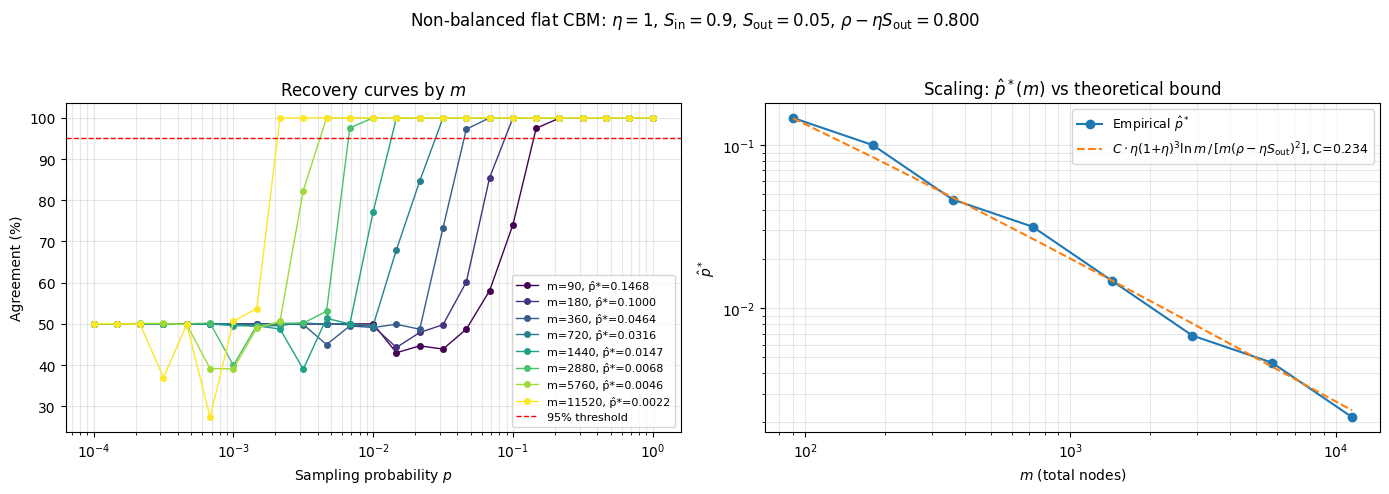

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_agr_eta1.png


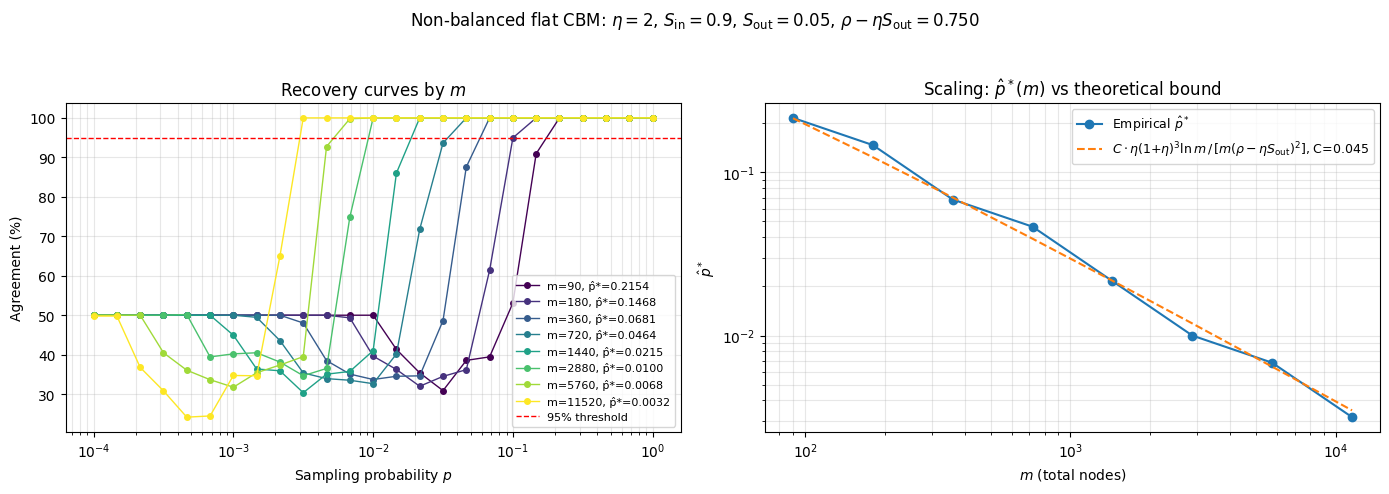

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_agr_eta2.png


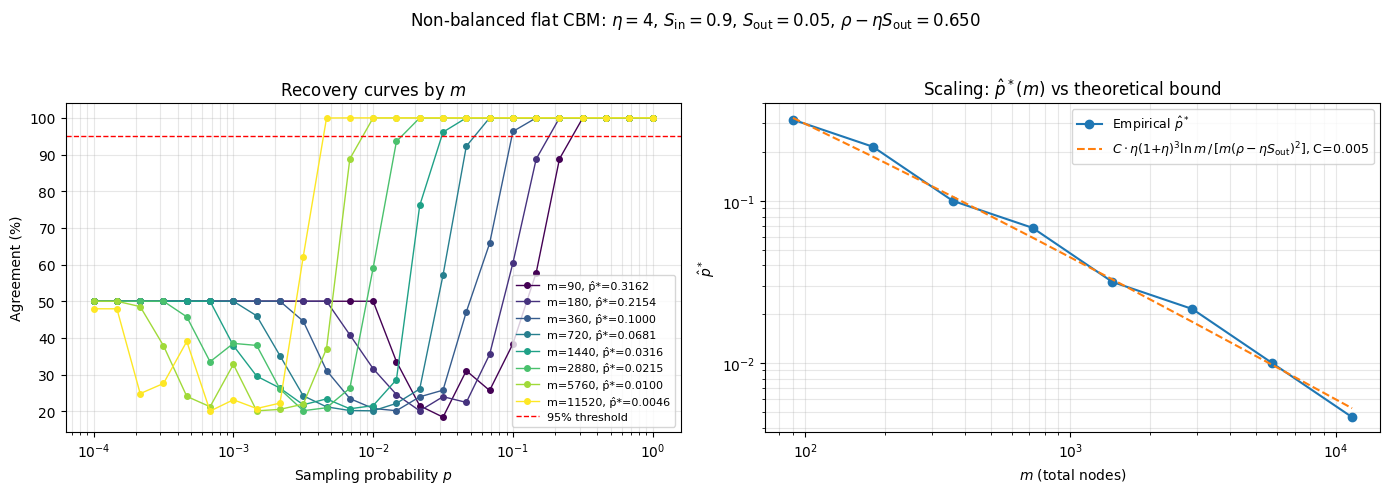

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_agr_eta4.png


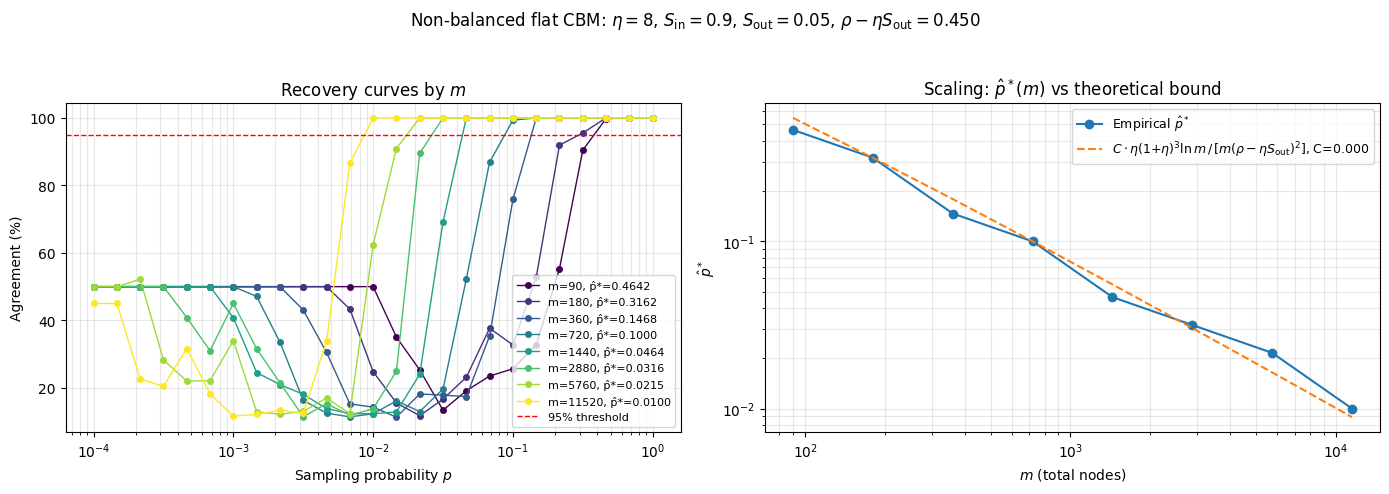

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_agr_eta8.png


In [6]:
save_dir = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

for eta in ETA_VALUES:
    C = C_per_eta[eta]
    margin = rho_global - eta * S_OUT

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        fr"Non-balanced flat CBM: $\eta={eta}$, $S_{{\mathrm{{in}}}}={S_IN}$, "
        fr"$S_{{\mathrm{{out}}}}={S_OUT}$, $\rho-\eta S_{{\mathrm{{out}}}}={margin:.3f}$"
    )

    # ---------- Left panel: recovery curves ----------
    cmap = plt.get_cmap("viridis")
    sub_agg = df_agg[df_agg.eta == eta]
    sub_thr = df_thresholds[df_thresholds.eta == eta]
    p_star_lookup = dict(zip(sub_thr["m"], sub_thr["p_star"]))

    ms = ms_for(eta)
    for i, m in enumerate(ms):
        curve = sub_agg[sub_agg.m == m].sort_values("p")
        color = cmap(i / max(1, len(ms) - 1))
        p_star = p_star_lookup.get(m)
        label_p = f"{p_star:.4f}" if p_star is not None and np.isfinite(p_star) else "n/a"
        ax_l.plot(
            curve["p"], 100.0 * curve["agreement"],
            "-o", color=color, ms=4, lw=1,
            label=f"m={m}, p̂*={label_p}",
        )

    ax_l.axhline(100.0 * RECOVERY_THRESHOLD, color="red", ls="--", lw=1,
                 label=f"{int(RECOVERY_THRESHOLD*100)}% threshold")
    ax_l.set_xscale("log")
    ax_l.set_xlabel("Sampling probability $p$")
    ax_l.set_ylabel("Agreement (%)")
    ax_l.set_title("Recovery curves by $m$")
    ax_l.legend(fontsize=8, loc="lower right")
    ax_l.grid(True, which="both", alpha=0.3)

    # ---------- Right panel: p* vs m + theory overlay ----------
    df_r = sub_thr.dropna(subset=["p_star"]).sort_values("m")
    if not df_r.empty:
        ax_r.plot(df_r["m"], df_r["p_star"], "-o", label=r"Empirical $\hat{p}^*$")

    if np.isfinite(C):
        m_grid = np.array(ms, dtype=float)
        # C · η(1+η)³ · ln(m) / [m · (ρ−η·S_out)²]  — decreases with m like ln(m)/m
        theory = C * eta * (1 + eta) ** 3 * np.log(m_grid) / (m_grid * margin ** 2)
        label  = (
            r"$C \cdot \eta(1{+}\eta)^3 \ln m\,/\,[m(\rho - \eta S_{\mathrm{out}})^2]$"
            f", C={C:.3f}"
        )
        ax_r.plot(m_grid, theory, "--", label=label)

    ax_r.set_xscale("log")
    ax_r.set_yscale("log")
    ax_r.set_xlabel("$m$ (total nodes)")
    ax_r.set_ylabel(r"$\hat{p}^*$")
    ax_r.set_title(r"Scaling: $\hat{p}^*(m)$ vs theoretical bound")
    ax_r.legend(fontsize=9)
    ax_r.grid(True, which="both", alpha=0.3)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    savepath = save_dir / f"pstar_synth_agr_eta{eta}.png"
    fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {savepath}")

# NMI recovery (alternative metric)

The cells above score recovery with **sign-agreement** (`compute_recovery`), which floors at
0.5 (chance), needs a `max(s, 1-s)` sign fix, and a `p·n < 1` degenerate floor. Here we retell
the same story with **normalized mutual information (NMI)** of the two sign-bipartitions.
NMI is label-permutation invariant (no sign fix), chance ≈ 0, perfect = 1 — the same cluster
recovery metric the rest of the repo reports (`partition_nmi_M`, `_binary_nmi`).

**The sweep is _not_ re-run.** `run_sweep` (Cell 4) already cached every sub-sampled Fiedler
vector on disk. `load_or_extend_metrics` computes NMI directly from those cached vectors and
merges it into each trial's `metrics.json` — so this section costs only a few `sklearn` calls,
not another 25×20-trial sub-sampling pass. All agreement cells and outputs above are untouched.

In [7]:
# Back-fill NMI onto the cached Fiedler vectors — no resampling.
# run_sweep reuses the cached fiedler_hat from Cell 4 and computes only the
# missing "nmi" metric, iterating the exact P_GRID (clean float p, matching the
# agreement df_agg). We do NOT use load_or_extend_metrics here: it reparses p
# from the 4-decimal cache key, which collapses the two smallest grid points
# and rounds the x-axis away from P_GRID.
nmi_rows = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        n1, n2, S, fiedler_full = full_results[eta][m]
        full_key = make_full_key("flat_cbm", eta=eta, n=m, s_in=S_IN, s_out=S_OUT)
        df_nm = run_sweep(
            CACHE_DIR, full_key, S, fiedler_full, P_GRID, N_TRIALS,
            metrics={"nmi": compute_nmi}, progress=False,
        )
        df_nm["eta"] = eta
        df_nm["m"]   = m
        nmi_rows.append(df_nm)

df_long_nmi = pd.concat(nmi_rows, ignore_index=True)
print(f"df_long_nmi shape: {df_long_nmi.shape}")
df_long_nmi.head()

df_long_nmi shape: (16000, 6)


,full_key,p,seed,nmi,eta,m
0,flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500,0.0001,0,0.020589,1,90
1,flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500,0.0001,1,0.020589,1,90
2,flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500,0.0001,2,0.020589,1,90
3,flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500,0.0001,3,0.020589,1,90
4,flat_cbm_eta0001_n0090_s_in0p9000_s_out0p0500,0.0001,4,0.020589,1,90


In [8]:
# Mean NMI per (eta, m, p). No max(s,1-s) / p·n<1 floor: NMI is naturally
# sign-invariant and honest (≈0) at low p.
df_agg_nmi = (
    df_long_nmi.groupby(["eta", "m", "p"], as_index=False)["nmi"].mean()
)
print(f"df_agg_nmi shape: {df_agg_nmi.shape}")
df_agg_nmi.head()

df_agg_nmi shape: (800, 4)


,eta,m,p,nmi
0,1,90,0.000100,0.020589
1,1,90,0.000147,0.020589
2,1,90,0.000215,0.020589
3,1,90,0.000316,0.030652
4,1,90,0.000464,0.022311


In [9]:
# p̂* and constant C, now using NMI. Same threshold (0.95) and same theory_scale
# as the agreement version. NMI is a stricter bar near the transition, so p̂* and
# C generally shift up relative to the agreement fit — expected.
threshold_rows_nmi = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        sub = df_agg_nmi[(df_agg_nmi.eta == eta) & (df_agg_nmi.m == m)].sort_values("p")
        p_star = find_threshold_p_star(
            sub["p"].to_numpy(),
            sub["nmi"].to_numpy(),
            threshold=RECOVERY_THRESHOLD,
        )
        margin      = rho_global - eta * S_OUT
        denom_sq    = margin ** 2
        theory_scale = eta * (1 + eta) ** 3 * np.log(m) / (m * denom_sq)
        threshold_rows_nmi.append({
            "eta": eta, "m": m,
            "p_star": p_star,
            "margin": margin,
            "theory_scale": theory_scale,
        })

df_thresholds_nmi = pd.DataFrame(threshold_rows_nmi)
# {(eta, m): p*} for the figure cell's C report
pstar_nmi = {(r["eta"], r["m"]): r["p_star"] for r in threshold_rows_nmi}
METRIC_LABEL = "NMI"

C_per_eta_nmi = {}
for eta in ETA_VALUES:
    sub = df_thresholds_nmi[(df_thresholds_nmi.eta == eta) & df_thresholds_nmi.p_star.notna()]
    C_per_eta_nmi[eta] = (
        float(np.median(sub["p_star"] / sub["theory_scale"])) if not sub.empty else float("nan")
    )

print("Fitted C per η (NMI):")
for eta, C in C_per_eta_nmi.items():
    print(f"  η={eta}: C = {C:.4f}")

df_thresholds_nmi

Fitted C per η (NMI):
  η=1: C = 0.2619
  η=2: C = 0.0447
  η=4: C = 0.0055
  η=8: C = 0.0004


,eta,m,p_star,margin,theory_scale
0,1,90,0.215443,0.80,0.624974
1,1,180,0.100000,0.80,0.360622
2,1,360,0.068129,0.80,0.204379
3,1,720,0.031623,0.80,0.114223
4,1,1440,0.014678,0.80,0.063128
5,1,2880,0.006813,0.80,0.034573
6,1,5760,0.004642,0.80,0.018791
7,1,11520,0.002154,0.80,0.010147
8,2,90,0.215443,0.75,4.799797
9,2,180,0.146780,0.75,2.769577


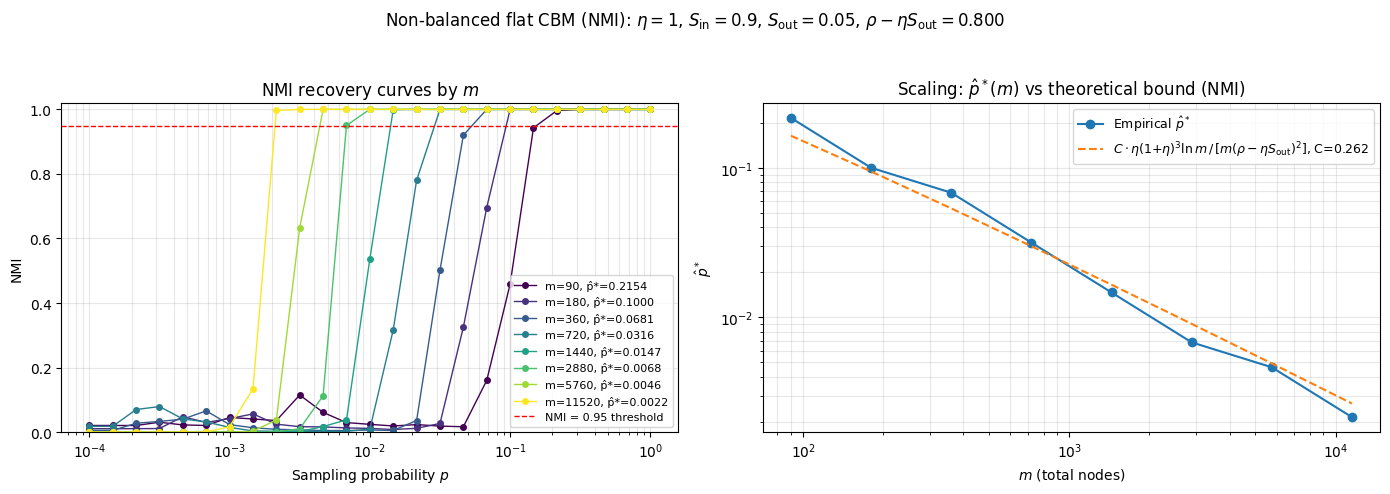

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_nmi_eta1.png


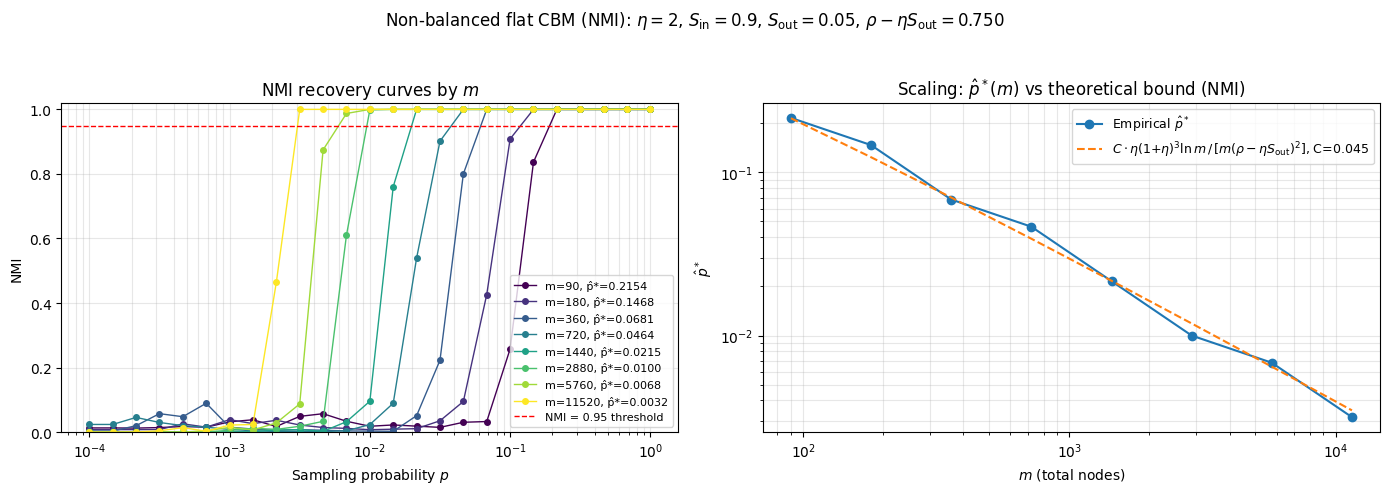

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_nmi_eta2.png


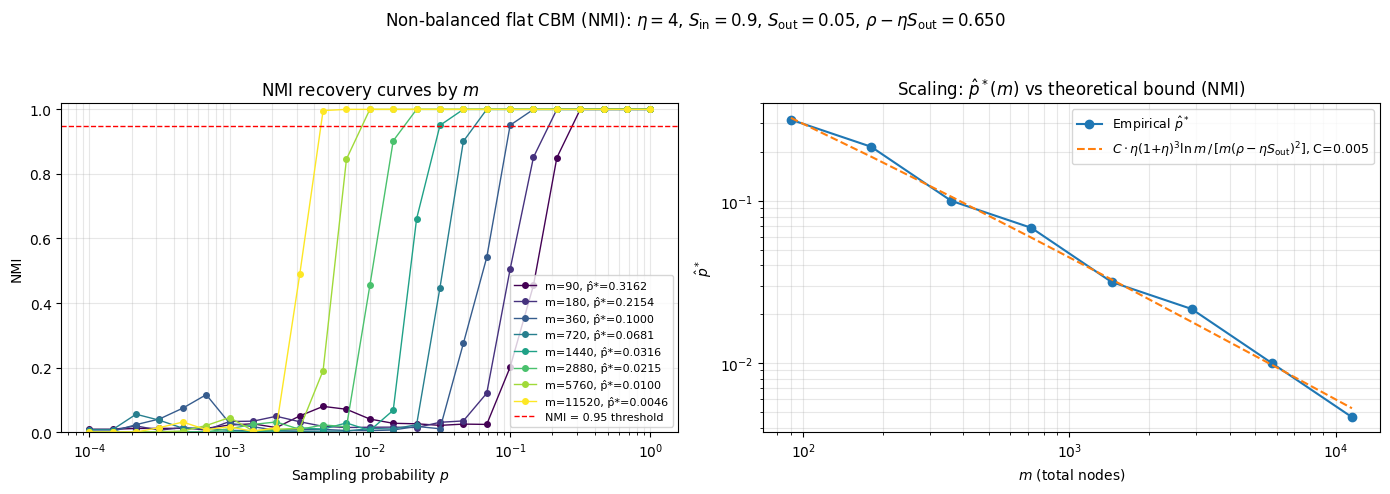

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_nmi_eta4.png


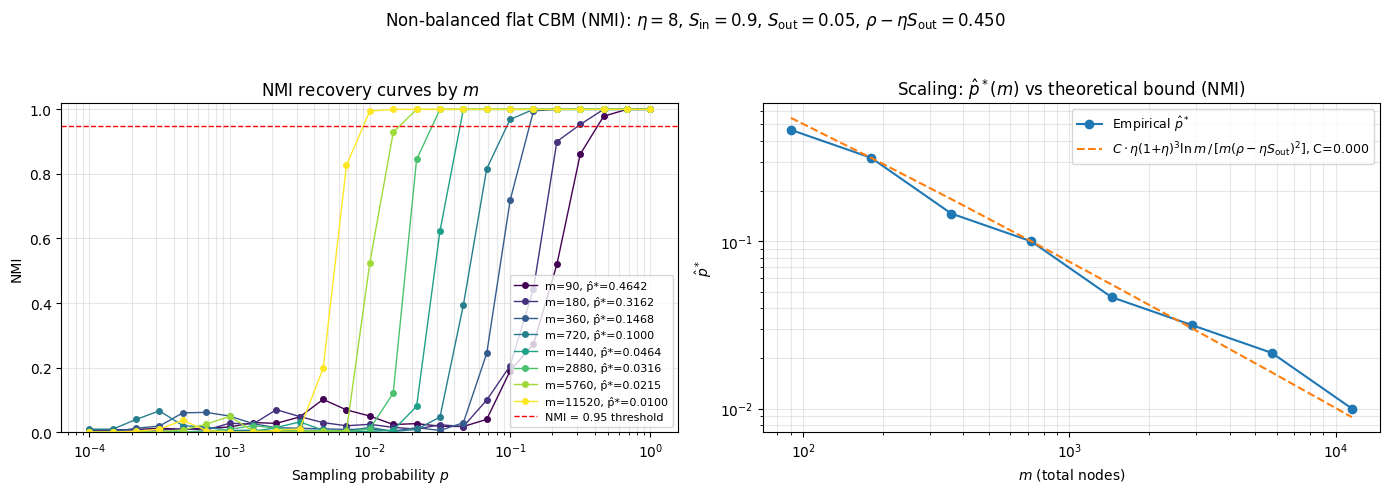

Saved → /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_synth_nmi_eta8.png


In [10]:
# Main-text synthesized figure: ONE file per eta, tiled 2x2 by LaTeX -- the same
# plot_pstar_pair used by the generated-regime figure (eta_pool_sweep.ipynb), so
# the two figures share panel layout, type sizes, ticks and reference curve. The
# eta lives in the LaTeX subcaption, so it appears nowhere in the image.
#
# plot_pstar_pair wants per-trial arrays keyed {(m, eta): [trials x len(P_GRID)]};
# df_long_nmi is long-form, so pivot it back.
save_dir = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

results_nmi = {}
for (eta, m), grp in df_long_nmi.groupby(["eta", "m"]):
    wide = grp.pivot_table(index="seed", columns="p", values="nmi", aggfunc="mean")
    results_nmi[(m, eta)] = wide.reindex(columns=P_GRID).to_numpy()

for eta in ETA_VALUES:
    ms = ms_for(eta)
    plot_pstar_pair(
        results_nmi, P_GRID, eta, ms,
        metric_label=METRIC_LABEL, agg="mean", threshold=RECOVERY_THRESHOLD,
        n_ticks=[100, 1000, 10000],          # m spans 90..12288 here, not 500..8000
        size_label=r"$m$ (total nodes)",
        savepath=save_dir / f"pstar_synth_nmi_eta{eta}.png",
    )
    xs = np.array([m for m in ms if np.isfinite(pstar_nmi.get((eta, m), np.nan))], float)
    ys = np.array([pstar_nmi[(eta, m)] for m in xs.astype(int)], float)
    if len(xs) >= 2:
        C, spread = median_ratio_C(xs, ys)
        print(f"  eta={eta:>2}: C={C:6.2f}  per-point spread={spread:5.1f}x  "
              f"points={len(xs)}/{len(ms)}")
